I. SIESTA

SIESTA is a linear combination of atomic orbitals (LCAO) Density Functional Theory (DFT) code that employs norm‑conserving pseudopotentials and highly efficient numerical atomic basis sets. In this tutorial, all calculations were carried out using SIESTA 5.4.2 together with PseudoDojo-curated pseudopotentials to ensure consistency and high transferability.

For the electronic structure calculations, we used the standard double‑zeta polarized (DZP) basis set distributed with SIESTA, which provides a good balance between accuracy and computational cost for typical materials simulations.

The Atomistic Simulation Environment (ASE) served as the workflow manager, handling input generation, job execution, and post‑processing. Instead of relying on SIESTA’s built‑in geometry optimization routines, all structural relaxations were performed using ASE’s optimizers, which offer more flexibility and tighter integration with Python-based workflows.

Single‑point calculation performed with SIESTA through ASE introduces the essential structure of a SIESTA workflow: defining the atomic system, selecting the basis set and pseudopotentials, configuring the calculator, and executing the run to obtain the electronic ground‑state properties without performing any geometry optimization.

In [2]:
from ase import Atoms
from ase.build import bulk
from ase.calculators.siesta import Siesta
from ase.units import Ry
from ase.visualize import view
import os


#create a new directory for the calculation

os.mkdir("c2_siesta")
os.chdir("c2_siesta")

# use ASE to create a diamond structure of carbon

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

# Minimal Siesta calculator

atoms.calc = Siesta(label='c2', # system label
                        xc='PBE', # exchange-correlation functional
                        pseudo_path='../pseudopotentials/siesta', #path to pseudopotentials
                        pseudo_qualifier='gga', #in necessary, specify the qualifier for the pseudopotentials
                        symlink_pseudos=True,
                        mesh_cutoff=200 * Ry, # cutoff for the real-space grid
                        energy_shift=0.01 * Ry,
                        basis_set='DZP', # basis set
                        spin='non-polarized', # spin configuration
                        kpts=(4, 4, 4), # k-point grid
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100}, # additional arguments for the SIESTA input file
               )

energy = atoms.get_total_energy() # execute the calculation and get the total energy

os.chdir("../")

print("Energy:", energy)

view(atoms, viewer='x3d') # atomistic visualization of the structure using x3d viewer in IPython



Energy: -1308.986275


Job completed


2. Converging the k‑point mesh in SIESTA is a critical prerequisite for obtaining reliable and reproducible results. The required k‑point density depends on the Bravais lattice of the system and scales with the reciprocal‑space dimensions of the periodic simulation cell. In practice, this means that larger real‑space cells require fewer k‑points, while smaller cells demand a denser mesh. The appropriate k‑point grid must be determined specifically for the system under study. It cannot—and should not—be copied from another calculation, even if the material appears similar. Each structure has its own reciprocal‑space characteristics, and the optimal grid is therefore unique.A standard way to determine the correct mesh is to converge the total energy with respect to the k‑point sampling. By systematically increasing the grid density and monitoring how the total energy changes, one can identify the smallest mesh that yields stable, well‑converged results. This procedure ensures that all subsequent calculations—geometry optimizations, electronic structure analysis, or property evaluations—are built on a solid numerical foundation.

Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed


k-points: 1
Energy: -1293.182263


Job completed


k-points: 2
Energy: -1308.23107


Job completed


...

Job completed


k-points: 6
Energy: -1308.995062


Job completed


k-points: 7
Energy: -1308.995312
k-points: 8
Energy: -1308.995333


Job completed


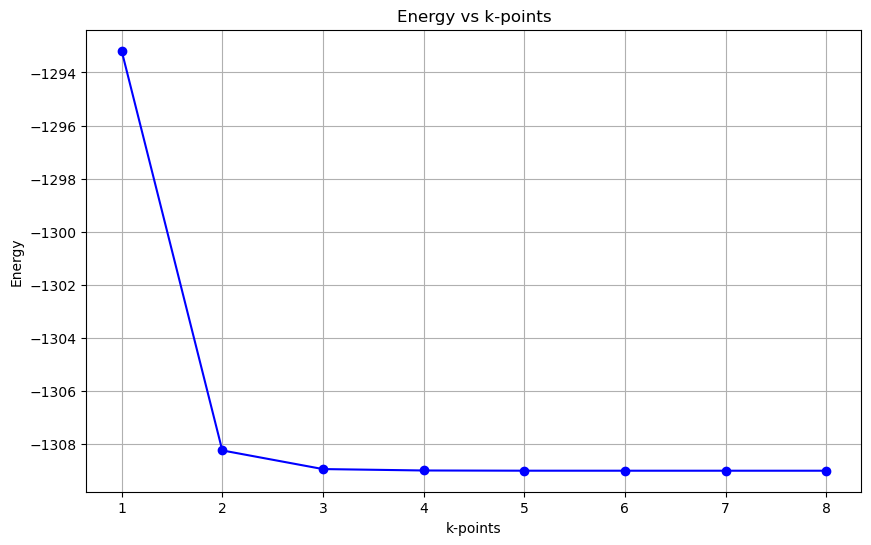

In [3]:
from ase import Atoms
from ase.calculators.siesta import Siesta
import os
from ase.build import bulk
from ase.units import Ry
import numpy as np
import matplotlib.pyplot as plt

os.mkdir("c2_siesta_kpts")
os.chdir("c2_siesta_kpts")

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

kk_array = []
energy_array = []

for kk in range(1, 9, 1): # loop over k-points from 1x1x1 to 8x8x8
 
    atoms.calc = Siesta(label='c2',
                            xc='PBE',
                            pseudo_path='../pseudopotentials/siesta',
                            pseudo_qualifier='gga',
                            symlink_pseudos=True,
                            mesh_cutoff=200 * Ry,
                            energy_shift=0.01 * Ry,
                            basis_set='DZP',
                            spin='non-polarized',
                            kpts=(kk, kk, kk),
                            fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
                )
    energy = atoms.get_total_energy()
    print("k-points:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)

# Plot k-point energy convergence

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs k-points')  # Add a title to the plot
plt.xlabel('k-points')  # Label for the x-axis
plt.ylabel('Energy')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")


3. SIESTA evaluates the electronic density and related quantities on a real‑space integration grid. The quality of this grid has a direct impact on the numerical stability of the calculation. A fine real‑space grid leads to well‑converged energies and forces, ensuring smooth potential surfaces and reliable structural optimization. In contrast, an insufficiently dense grid can introduce numerical artifacts known as the eggbox effect, where the total energy and forces fluctuate as atoms move relative to the underlying grid. These fluctuations degrade the accuracy of geometry optimizations and any properties derived from them. For this reason, converging the real‑space grid (via the MeshCutoff parameter) is considered good practice. By systematically increasing the grid cutoff and monitoring the stability of the total energy and forces, one can identify a cutoff value that eliminates eggbox artifacts and provides consistent, physically meaningful results for the system under study.

Job completed


k-points: 150
Energy: -1308.993429


Job completed


k-points: 160
Energy: -1308.99343


Job completed


...

Job completed


k-points: 230
Energy: -1308.994798


Job completed


k-points: 240
Energy: -1308.994798
k-points: 250
Energy: -1308.994798


Job completed


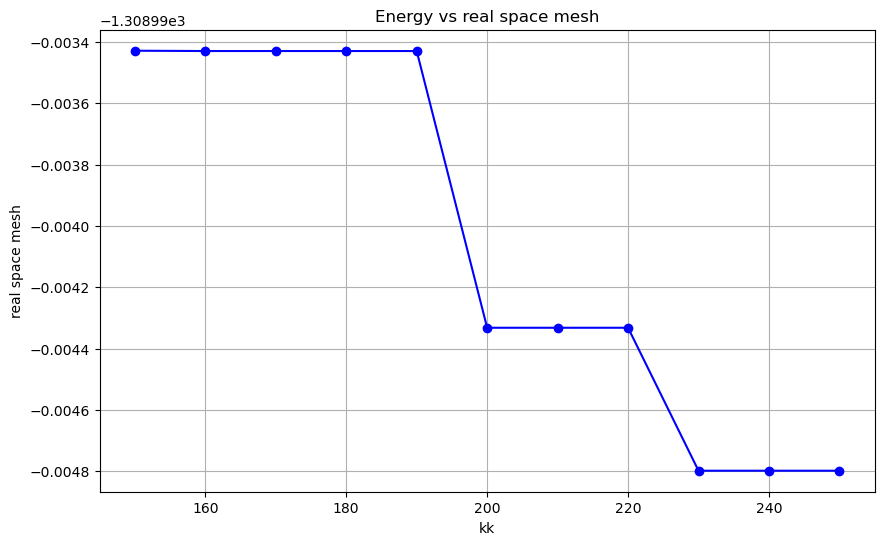

In [4]:
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.build import bulk
import os
from ase.units import Ry
import numpy as np
import matplotlib.pyplot as plt

os.mkdir("c2_siesta_cutoff")
os.chdir("c2_siesta_cutoff")

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

kk_array = []
energy_array = []

for kk in range(150, 260, 10):
    # Minimal Vasp calculator for testing
    atoms.calc = Siesta(label='c2',
                            xc='PBE',
                            pseudo_path='../pseudopotentials/siesta',
                            pseudo_qualifier='gga',
                            symlink_pseudos=True,
                            mesh_cutoff=kk * Ry,
                            energy_shift=0.01 * Ry,
                            basis_set='DZP',
                            spin='non-polarized',
                            kpts=(5, 5, 5),
                            fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
                )
    
    energy = atoms.get_total_energy()
    print("k-points:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)
# Run a single-point calculation

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs real space mesh')  # Add a title to the plot
plt.xlabel('kk')  # Label for the x-axis
plt.ylabel('real space mesh')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")


4. Geometry and lattice optimization in this tutorial are performed using the ASE optimization algorithms, while SIESTA is used strictly as a force and energy calculator. This separation of roles is intentional. Many DFT packages in materials science—including SIESTA—provide basic geometry optimizers that are functional but often limited in robustness, flexibility, and convergence behavior. In contrast, external frameworks such as ASE offer modern, well‑tested optimization algorithms that integrate smoothly with Python workflows and provide more reliable convergence for both atomic positions and cell degrees of freedom. The optimizer used here is the Broyden–Fletcher–Goldfarb–Shanno (BFGS) algorithm. BFGS is a quasi‑Newton method that combines gradient information with an evolving approximation of the inverse Hessian. This allows it to accelerate convergence by effectively estimating curvature without performing expensive second‑derivative calculations. For comparison, SIESTA’s built‑in Conjugate Gradient (CG) optimizer relies solely on first‑order information. CG constructs search directions that are conjugate with respect to the Hessian but never stores or approximates the Hessian itself. While efficient, CG typically converges more slowly and less smoothly than quasi‑Newton methods, especially for complex materials or systems with soft modes. To enable full lattice optimization, ASE provides the UnitCellFilter class, which exposes the cell degrees of freedom to the optimizer. When wrapped around the atomic configuration, UnitCellFilter ensures that both atomic positions and lattice vectors are updated consistently during the optimization process.

In [5]:
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
from ase.build import bulk
from ase.visualize import view
import os
from ase.optimize.bfgs import BFGS
from ase.filters import UnitCellFilter
from ase.io import write


os.mkdir("c2_siesta_opt")
os.chdir("c2_siesta_opt")

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

print("Initial cell:")
print(atoms.cell) # print the initial cell parameters before the optimization

# Minimal Siesta calculator for testing
atoms.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 5),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
               )

energy = atoms.get_total_energy()

ucf = UnitCellFilter(atoms) # set up a unit cell filter to allow optimization of the cell parameters
opt = BFGS(ucf, trajectory='cellopt.traj') # set up a BFGS optimizer to optimize the cell parameters of the structure
opt.run(fmax=0.01) # converge the optimization until the maximum force is below 0.01 eV/Å

# Run a single-point calculation

os.chdir("../")

print("Final cell:")
print(atoms.cell) # print the optimized cell parameters after the optimization is complete

write('cell_siesta.traj', atoms) # the optimization trajectory is saved as a set of geometry snapshots in a .traj file, which can be visualized later using ASE or other visualization tools

view(atoms, viewer='x3d')

Initial cell:
Cell([3.567, 3.567, 3.567])


Job completed


      Step     Time          Energy          fmax
BFGS:    0 10:31:29    -1308.994797        0.337870


Job completed


BFGS:    1 10:31:42    -1308.999467        0.307149


Job completed


BFGS:    2 10:31:59    -1309.022572        0.015012
BFGS:    3 10:32:13    -1309.022615        0.001113
Final cell:
Cell([[3.591774264265943, -1.167699457531732e-19, -1.5857847437153633e-20], [5.083304272601093e-20, 3.591774264265943, 9.339182798140684e-21], [-2.7199825009546105e-20, -2.1505744230660708e-21, 3.591774264265943]])


Job completed


5. The Density of States (DOS) is one of the fundamental electronic properties computed in Density Functional Theory. It describes how many electronic states are available at each energy level and provides direct insight into the material’s electronic behavior. By examining the DOS, we can identify the valence band, conduction band, and the band gap, which together determine whether a material behaves as an insulator, semiconductor, or metal. Because of this, DOS analysis is an essential step in interpreting and understanding the electronic structure obtained from DFT calculations.

Job completed


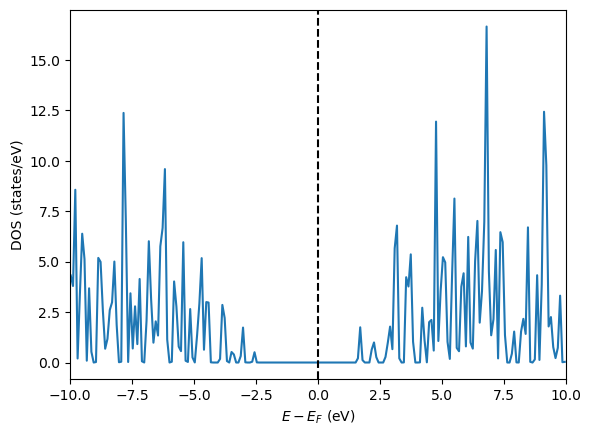

In [6]:
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
import os
from ase.io import read
from ase.dft.dos import DOS # ASE calss for calculating the density of states (DOS)
import matplotlib.pyplot as plt

atoms = read('cell_siesta.traj')
atoms.pbc=True

os.mkdir("c2_siesta_dos")
os.chdir("c2_siesta_dos")

atoms.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 5),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100, 'WriteEigenvalues': True, 'SaveHS': True,},
               )

energy = atoms.get_potential_energy()

dos = DOS(atoms.calc,
          width=0.05,
          npts=3000)

E = dos.get_energies()
D = dos.get_dos()

os.chdir("../")

# Select only -10 to +10 eV around Ef
mask = (E >= -10) & (E <= 10)

plt.plot(E[mask], D[mask])
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-10, 10)
plt.xlabel(r'$E - E_F$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.show()


6. While bulk calculations are essential for understanding intrinsic material properties, many applications in catalysis, electronics, and nanotechnology require detailed knowledge of surface properties. In periodic DFT codes such as SIESTA, surfaces are modeled using slab geometries, where a finite number of atomic layers represent the surface and vacuum is added to isolate it from periodic images. ASE provides convenient tools for constructing such slabs. Using its built‑in ase.build.surface function, one can cleave a bulk crystal along a chosen set of Miller indices. In this tutorial, we generate the diamond (100) surface by slicing the bulk diamond structure along the (1 0 0) plane and adding sufficient vacuum to avoid interactions between repeated slabs. Once the slab is constructed, the geometry optimization is applied only to the atomic positions, not to the cell parameters. The lattice constants are optimized at the bulk level and then kept fixed during surface relaxation. This ensures that the slab inherits physically meaningful bulk geometry while allowing the surface layers to relax into their energetically preferred configuration.

In [7]:
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
from ase.build import surface
from ase.visualize import view
from ase.io import read
from ase.io import write
import os
from ase.optimize.bfgs import BFGS

atoms = read('cell_siesta.traj')
atoms.pbc=True

slab = surface(atoms, (1,0,0), 2, vacuum=10.0) # create a slab of the optimized structure with 4 layers and 15 Å of vacuum
slab.pbc=True

# center slab in vacuum
slab.center(axis=2)


os.mkdir("c2_siesta_slab_opt")
os.chdir("c2_siesta_slab_opt")

# Minimal Vasp calculator for testing
slab.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
               )

energy = slab.get_total_energy()

opt = BFGS(slab, trajectory='cellopt.traj')
opt.run(fmax=0.03)

# Run a single-point calculation

os.chdir("../")

write('slab_siesta.traj', slab)


view(slab, viewer='x3d')

Job completed


      Step     Time          Energy          fmax
BFGS:    0 10:33:44    -2603.623001        2.261050


Job completed


BFGS:    1 10:34:32    -2603.969982        0.840001


Job completed


...

Job completed


BFGS:    6 10:37:44    -2604.031869        0.096371


Job completed


BFGS:    7 10:38:13    -2604.032463        0.031555
BFGS:    8 10:38:28    -2604.032526        0.003869


Job completed


7. The surface Density of States (DOS) provides essential insight into how a surface modifies the electronic structure of a material. Unlike the bulk, where all bonds are fully coordinated, a surface exposes atoms with unsatisfied valence—leading to electronic features that can differ dramatically from the bulk behavior. The DOS of the diamond (100) surface illustrates this clearly. Although bulk diamond is a wide‑band‑gap insulator, the (100) surface shows no band gap and exhibits metallic character. At first glance this result may seem counterintuitive. However, the explanation lies in the orbital configuration of the surface atoms. The top‑layer carbon atoms possess dangling bonds that are not compensated by neighboring atoms. These dangling‑bond states fall within the band gap of bulk diamond and create partially filled surface states, giving rise to metallic behavior. This metallicity is not just a computational artifact—it is consistent with experimental observations, where clean diamond surfaces often display surface conductivity due to these unsaturated bonds. Understanding this effect is crucial when studying surface chemistry, adsorption, catalysis, or electronic devices based on diamond surfaces.

Job completed


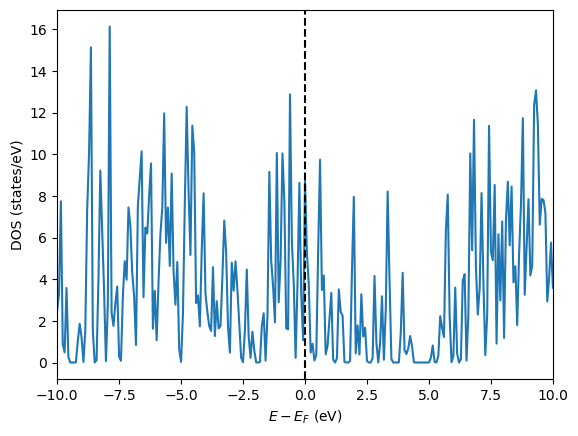

In [8]:
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
import os
from ase.io import read
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

atoms = read('slab_siesta.traj')
atoms.pbc=True

os.mkdir("c2_siesta_dos_slab")
os.chdir("c2_siesta_dos_slab")

atoms.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100, 'WriteEigenvalues': True, 'SaveHS': True,},
               )

energy = atoms.get_potential_energy()

dos = DOS(atoms.calc,
          width=0.05,
          npts=3000)

E = dos.get_energies()
D = dos.get_dos()

os.chdir("../")

# Select only -10 to +10 eV around Ef
mask = (E >= -10) & (E <= 10)

plt.plot(E[mask], D[mask])
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-10, 10)
plt.xlabel(r'$E - E_F$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.show()


8. In reality, a pristine diamond surface exists only under ultrahigh‑vacuum (UHV) conditions and even then only for short periods of time. Under ambient or experimental conditions, the surface rapidly becomes passivated, most commonly by hydrogen atoms. To model realistic surfaces, we therefore construct a hydrogen‑terminated diamond (100) slab and optimize its geometry again. ASE provides convenient tools for building such passivated surfaces. First, we identify the top and bottom surface carbon atoms, which are the ones carrying dangling bonds. Hydrogen atoms are then added to these sites to saturate the dangling bonds and restore the insulating character of the surface. To avoid artificial interactions between hydrogens, we arrange them in a pattern that maximizes the distance between neighboring H atoms, ensuring a physically meaningful termination. After adding the hydrogens, the slab is relaxed again, allowing both the surface carbon atoms and the hydrogen atoms to settle into their energetically preferred configuration. This passivated surface serves as a more realistic model for studying electronic properties, adsorption, and surface chemistry under typical experimental conditions.

In [9]:
import numpy as np
from ase.io import read
from ase.build import surface
from ase import Atom
from ase.visualize import view


atoms = read('cell_siesta.traj')
atoms.pbc = True

slab = surface(atoms, (1,0,0), 2, vacuum=10.0)
slab.center(axis=2)

# Highest carbon z coordinate
zmax = max(atom.position[2] for atom in slab if atom.symbol == 'C')

# Select top-layer carbon atoms
tol = 0.5  # Å tolerance
top_carbons = [i for i, atom in enumerate(slab)
               if atom.symbol == 'C' and zmax - atom.position[2] < tol]

CH = 0.8


pos = slab[top_carbons[0]].position + np.array([-0.5, -0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[0]].position + np.array([0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position + np.array([-0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position + np.array([0.5, -0.5, CH])
slab.append(Atom('H', pos))


# Highest carbon z coordinate
zmin = min(atom.position[2] for atom in slab if atom.symbol == 'C')

top_carbons = [i for i, atom in enumerate(slab)
               if atom.symbol == 'C' and atom.position[2] - zmin < tol]


pos = slab[top_carbons[0]].position - np.array([-0.5, -0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[0]].position - np.array([0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position - np.array([-0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position - np.array([0.5, -0.5, CH])
slab.append(Atom('H', pos))

view(slab, viewer='x3d')

9. Self‑consistent field (SCF) convergence and geometry relaxation in LCAO‑based DFT codes such as SIESTA depend strongly on the quality of the initial atomic configuration. When the starting geometry is far from the true minimum, the SCF cycle may become unstable, stall, or fail to converge entirely. This is exactly what happens for the H‑passivated diamond (100) surface: the initial guess contains significant strain and unfavorable bond orientations, making the SCF procedure overly sensitive. A practical and widely used strategy in SIESTA is to temporarily loosen the computational settings to help the optimizer explore a broader region of configuration space. Reducing the basis‑set size, lowering the k‑point density, and decreasing the real‑space mesh cutoff all make the SCF cycle more forgiving. Although these settings are not suitable for final production calculations, they allow the geometry optimizer to move the system closer to a physically meaningful structure where full‑accuracy parameters can later be restored. In this tutorial, we apply this approach by reducing the k‑point mesh to 3×3×3 and lowering the real‑space grid cutoff to 170 Ry. With these relaxed settings, the SCF converges reliably, enabling the geometry optimizer to correct the initial distortions. Once the structure is sufficiently improved, the calculation can be repeated with fully converged parameters to obtain accurate energies and electronic properties.

In [10]:
import numpy as np
from ase.io import read
from ase.io import write
from ase.build import surface
from ase import Atom
from ase.visualize import view
from ase.calculators.siesta import Siesta
from ase.units import Ry
from ase.optimize.bfgs import BFGS
import os


atoms = read('cell_siesta.traj')
atoms.pbc = True

slab = surface(atoms, (1,0,0), 2, vacuum=10.0)
slab.center(axis=2)

# Highest carbon z coordinate
zmax = max(atom.position[2] for atom in slab if atom.symbol == 'C')

# Select top-layer carbon atoms
tol = 0.5  # Å tolerance
top_carbons = [i for i, atom in enumerate(slab)
               if atom.symbol == 'C' and zmax - atom.position[2] < tol]

# Add H atoms 1.09 Å above each top carbon
CH = 0.8


pos = slab[top_carbons[0]].position + np.array([-0.5, -0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[0]].position + np.array([0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position + np.array([-0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position + np.array([0.5, -0.5, CH])
slab.append(Atom('H', pos))


# Highest carbon z coordinate
zmin = min(atom.position[2] for atom in slab if atom.symbol == 'C')

top_carbons = [i for i, atom in enumerate(slab)
               if atom.symbol == 'C' and atom.position[2] - zmin < tol]


pos = slab[top_carbons[0]].position - np.array([-0.5, -0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[0]].position - np.array([0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position - np.array([-0.5, 0.5, CH])
slab.append(Atom('H', pos))

pos = slab[top_carbons[1]].position - np.array([0.5, -0.5, CH])
slab.append(Atom('H', pos))

os.mkdir("c2_siesta_slab_h_opt")
os.chdir("c2_siesta_slab_h_opt")

# Minimal Vasp calculator for testing
slab.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=170 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='SZP',
                        spin='non-polarized',
                        kpts=(3, 3, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
               )

energy = slab.get_total_energy()

opt = BFGS(slab, trajectory='cellopt.traj')
opt.run(fmax=0.03)

# Run a single-point calculation

os.chdir("../")

write('slab_h_siesta.traj', slab)


view(slab, viewer='x3d')

Job completed


      Step     Time          Energy          fmax
BFGS:    0 10:40:30    -2718.438802        4.527510


Job completed


BFGS:    1 10:41:06    -2719.981279        1.780527


Job completed


...

Job completed


BFGS:   87 10:57:06    -2728.277734        0.036807


Job completed


BFGS:   88 10:57:09    -2728.277883        0.031861
BFGS:   89 10:57:13    -2728.278001        0.026881


Job completed


10. The fully optimized geometry differs substantially from our initial guess, confirming that the original configuration was far from the true minimum. After relaxing the structure with the loosened computational settings, we restored the high‑accuracy parameters. At this stage, the system was already close to equilibrium, and the SCF cycle was stable. As a result, the final high‑precision geometry optimization converged in only a few steps, demonstrating the effectiveness of the two‑stage relaxation strategy.

In [11]:
import numpy as np
from ase.io import read
from ase.io import write
from ase import Atom
from ase.visualize import view
from ase.calculators.siesta import Siesta
from ase.units import Ry
from ase.optimize.bfgs import BFGS
import os


atoms = read('slab_h_siesta.traj')
atoms.pbc = True

os.mkdir("c2_siesta_slab_h_opt_high")
os.chdir("c2_siesta_slab_h_opt_high")

# Minimal Vasp calculator for testing
slab.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
               )

energy = slab.get_total_energy()

opt = BFGS(slab, trajectory='cellopt.traj')
opt.run(fmax=0.03)

# Run a single-point calculation

os.chdir("../")

write('slab_h_siesta_high.traj', slab)


view(slab, viewer='x3d')

Job completed


      Step     Time          Energy          fmax
BFGS:    0 10:58:03    -2739.774410        0.689106


Job completed


BFGS:    1 10:58:28    -2739.814861        0.340932


Job completed


...

Job completed


BFGS:   10 11:00:42    -2739.856977        0.048349


Job completed


BFGS:   11 11:00:53    -2739.857401        0.039482
BFGS:   12 11:01:04    -2739.857721        0.029926


Job completed


11. The Density of States (DOS) of the hydrogen‑passivated diamond (100) surface shows a large band gap, closely matching that of bulk diamond. This behavior is expected: once the surface carbon atoms are saturated with hydrogen, the dangling‑bond states responsible for the metallic character of the pristine surface are removed. With these mid‑gap states eliminated, the electronic structure of the slab returns to that of an insulator, demonstrating that hydrogen termination effectively restores the bulk‑like electronic properties at the surface.

Job completed


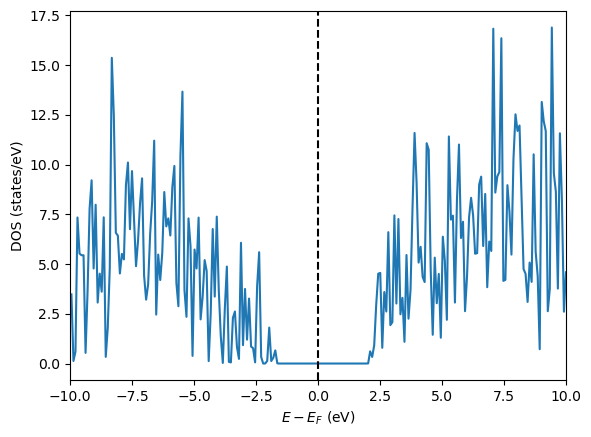

In [12]:
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
import os
from ase.io import read
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

atoms = read('slab_h_siesta_high.traj')
atoms.pbc=True

os.mkdir("c2_siesta_dos_slab_h")
os.chdir("c2_siesta_dos_slab_h")

atoms.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100, 'WriteEigenvalues': True, 'SaveHS': True,},
               )

energy = atoms.get_potential_energy()

dos = DOS(atoms.calc,
          width=0.05,
          npts=3000)

E = dos.get_energies()
D = dos.get_dos()

os.chdir("../")

# Select only -10 to +10 eV around Ef
mask = (E >= -10) & (E <= 10)

plt.plot(E[mask], D[mask])
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-10, 10)
plt.xlabel(r'$E - E_F$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.show()


12. The Density of States (DOS) tells us how electronic states are distributed relative to the Fermi level, but it does not provide the absolute energy of the Fermi level. In periodic DFT calculations, all eigenvalues are referenced to an arbitrary internal zero, determined by the basis set, pseudopotentials, and numerical setup. As a result, absolute energy levels cannot be compared directly between two different materials or even between two separate calculations of the same material using different computational parameters. To obtain meaningful, comparable energy references, we compute the work function or, more precisely, the ionization potential of the slab. This quantity gives the energy of the valence‑band maximum (VBM) relative to the vacuum level, which is the same physical reference for every slab. By anchoring the electronic structure to the vacuum level, we can compare band edges, Fermi levels, and work functions across different systems in a consistent way. To perform work‑function or ionization‑potential calculations, the slab must include a sufficiently thick vacuum region. The electrostatic potential must reach a flat plateau in the vacuum, indicating that the potential is constant and free from interactions with the slab. Once this plateau is identified, we extract the vacuum electrostatic potential and reference the VBM (or Fermi level) to it. SIESTA outputs the electrostatic potential on a real‑space grid in the file ElectrostaticPotential.grid.nc, which contains the volumetric data needed to compute the averaged potential along the slab normal. To generate this file, several options must be enabled in the SIESTA input: 'WriteEigenvalues': True,
'SaveHS': True, 'SaveElectrostaticPotential': True, 'WriteVH': True,


Job completed


Vacuum level = -0.909301 eV
Fermi level = -1.732426 eV
VBM = -3.493508 eV
CBM = 0.390725 eV

Vacuum - VBM (Ionization Potential) = 2.584207 eV
Vacuum - CBM (Electron Affinity)   = -1.300026 eV


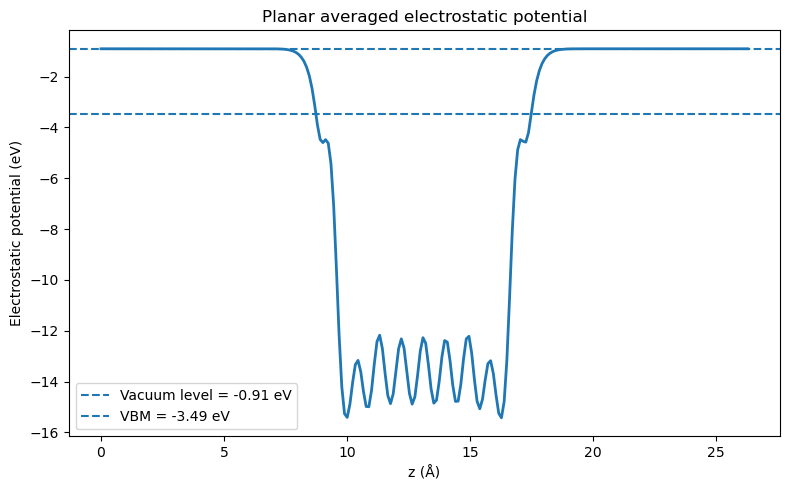

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import re
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
import os
from ase.io import read

slab = read('slab_h_siesta_high.traj')
slab.pbc=True

os.mkdir("c2_siesta_wf_slab_h")
os.chdir("c2_siesta_wf_slab_h")


slab.calc = Siesta(label='slab',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100, 'WriteEigenvalues': True, 'SaveHS': True,'SaveElectrostaticPotential': True, 'WriteVH': True,},
               )


energy = slab.get_potential_energy()

import sisl
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Read electrostatic potential
# --------------------------------------------------
grid = sisl.get_sile("ElectrostaticPotential.grid.nc").read_grid()

V = grid.grid

# planar average
V_z = V.mean(axis=(0,1))

# z coordinate
cell_z = grid.cell[2,2]
z = np.linspace(0, cell_z, len(V_z))

# --------------------------------------------------
# Vacuum level
# --------------------------------------------------
# for symmetric slab simply use the maximum value
V_vac = np.max(V_z)

# alternatively use averaging around plateau:
# vacuum_mask = z > (cell_z - 5.0)
# V_vac = np.mean(V_z[vacuum_mask])

print(f"Vacuum level = {V_vac:.6f} eV")

# --------------------------------------------------
# Read eigenvalues
# --------------------------------------------------
with open("slab.EIG") as f:
    lines = f.readlines()

# first line contains Fermi level
E_F = float(lines[0])

# collect all eigenvalues
eigs = []

for line in lines[2:]:
    parts = line.split()

    # skip band index at beginning of each k-point block
    if len(parts) > 0:
        try:
            int(parts[0])
            parts = parts[1:]
        except:
            pass

    for x in parts:
        try:
            eigs.append(float(x))
        except:
            pass

eigs = np.array(eigs)

# --------------------------------------------------
# Determine VBM and CBM
# --------------------------------------------------
occupied = eigs[eigs < E_F]
unoccupied = eigs[eigs > E_F]

VBM = occupied.max()
CBM = unoccupied.min()

print(f"Fermi level = {E_F:.6f} eV")
print(f"VBM = {VBM:.6f} eV")
print(f"CBM = {CBM:.6f} eV")

# --------------------------------------------------
# Ionization potential
# --------------------------------------------------
IP = V_vac - VBM

# Electron affinity if desired
EA = V_vac - CBM

print()
print(f"Vacuum - VBM (Ionization Potential) = {IP:.6f} eV")
print(f"Vacuum - CBM (Electron Affinity)   = {EA:.6f} eV")

# --------------------------------------------------
# Plot electrostatic potential
# --------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(z, V_z, lw=2)

plt.axhline(
    V_vac,
    linestyle='--',
    label=f'Vacuum level = {V_vac:.2f} eV'
)

plt.axhline(
    VBM,
    linestyle='--',
    label=f'VBM = {VBM:.2f} eV'
)

plt.xlabel("z (Å)")
plt.ylabel("Electrostatic potential (eV)")
plt.title("Planar averaged electrostatic potential")
plt.legend()

plt.tight_layout()
plt.show()

os.chdir("../")

The ionization potential of the hydrogen‑passivated diamond (100) slab is calculated to be 2.584207 eV, whereas the pristine diamond (100) surface exhibits a much higher value of 6.660054 eV. This dramatic difference is well‑known experimentally and highlights the crucial role of surface reconstruction and surface termination in determining electronic properties. Hydrogen termination fundamentally alters the surface electronic environment. By saturating the dangling bonds on the topmost carbon atoms, hydrogen atoms create a surface dipole layer that shifts the electrostatic potential downward. This dipole makes it energetically easier to remove an electron from the surface, resulting in a much lower ionization potential. In practical terms, the H‑terminated surface becomes far more favorable for electron emission, a property exploited in applications such as negative‑electron‑affinity (NEA) diamond devices. In contrast, the pristine diamond (100) surface lacks these stabilizing dipoles. Its unsaturated dangling bonds produce mid‑gap states and a higher surface potential, making electron extraction significantly more difficult. The high ionization potential reflects this unfavorable electronic environment. These results demonstrate how surface chemistry directly controls the electronic structure, and they emphasize the importance of accurate surface modeling when studying real materials or designing diamond‑based electronic and optoelectronic devices.

Vacuum level = 0.459113 eV
Fermi level = -6.185375 eV
VBM = -6.200940 eV
CBM = -6.181882 eV

Vacuum - VBM (Ionization Potential) = 6.660054 eV
Vacuum - CBM (Electron Affinity)   = 6.640995 eV


Job completed


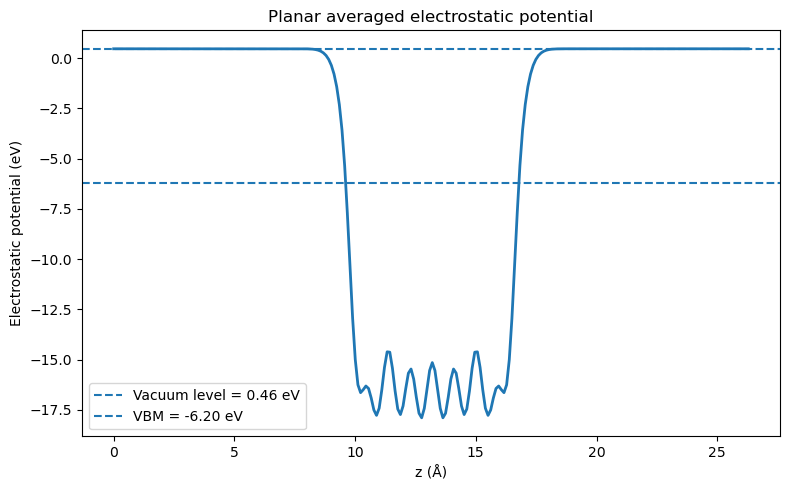

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import re
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry
import os
from ase.io import read
import sisl
import numpy as np
import matplotlib.pyplot as plt



slab = read('slab_siesta.traj')
slab.pbc=True

os.mkdir("c2_siesta_wf_slab_h_non")
os.chdir("c2_siesta_wf_slab_h_non")


slab.calc = Siesta(label='slab',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(5, 5, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100, 'WriteEigenvalues': True, 'SaveHS': True,'SaveElectrostaticPotential': True, 'WriteVH': True,},
               )


energy = slab.get_potential_energy()

# --------------------------------------------------
# Read electrostatic potential
# --------------------------------------------------
grid = sisl.get_sile("ElectrostaticPotential.grid.nc").read_grid()

V = grid.grid

# planar average
V_z = V.mean(axis=(0,1))

# z coordinate
cell_z = grid.cell[2,2]
z = np.linspace(0, cell_z, len(V_z))

# --------------------------------------------------
# Vacuum level
# --------------------------------------------------
# for symmetric slab simply use the maximum value
V_vac = np.max(V_z)

# alternatively use averaging around plateau:
# vacuum_mask = z > (cell_z - 5.0)
# V_vac = np.mean(V_z[vacuum_mask])

print(f"Vacuum level = {V_vac:.6f} eV")

# --------------------------------------------------
# Read eigenvalues
# --------------------------------------------------
with open("slab.EIG") as f:
    lines = f.readlines()

# first line contains Fermi level
E_F = float(lines[0])

# collect all eigenvalues
eigs = []

for line in lines[2:]:
    parts = line.split()

    # skip band index at beginning of each k-point block
    if len(parts) > 0:
        try:
            int(parts[0])
            parts = parts[1:]
        except:
            pass

    for x in parts:
        try:
            eigs.append(float(x))
        except:
            pass

eigs = np.array(eigs)

# --------------------------------------------------
# Determine VBM and CBM
# --------------------------------------------------
occupied = eigs[eigs < E_F]
unoccupied = eigs[eigs > E_F]

VBM = occupied.max()
CBM = unoccupied.min()

print(f"Fermi level = {E_F:.6f} eV")
print(f"VBM = {VBM:.6f} eV")
print(f"CBM = {CBM:.6f} eV")

# --------------------------------------------------
# Ionization potential
# --------------------------------------------------
IP = V_vac - VBM

# Electron affinity if desired
EA = V_vac - CBM

print()
print(f"Vacuum - VBM (Ionization Potential) = {IP:.6f} eV")
print(f"Vacuum - CBM (Electron Affinity)   = {EA:.6f} eV")

# --------------------------------------------------
# Plot electrostatic potential
# --------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(z, V_z, lw=2)

plt.axhline(
    V_vac,
    linestyle='--',
    label=f'Vacuum level = {V_vac:.2f} eV'
)

plt.axhline(
    VBM,
    linestyle='--',
    label=f'VBM = {VBM:.2f} eV'
)

plt.xlabel("z (Å)")
plt.ylabel("Electrostatic potential (eV)")
plt.title("Planar averaged electrostatic potential")
plt.legend()

plt.tight_layout()
plt.show()

os.chdir("../")

13. The Nudged Elastic Band (NEB) method is a computational technique used to determine the minimum‑energy path (MEP) between two known states of a system—typically an initial configuration and a final configuration connected by some physical process such as diffusion, adsorption, desorption, or a chemical reaction. Instead of guessing the transition pathway, NEB constructs a series of intermediate “images” of the system and links them together like an elastic band. During optimization, forces perpendicular to the path push the images toward the true MEP, while spring forces along the path maintain a smooth connection between them. The result is a physically meaningful reaction pathway and an accurate estimate of the activation energy barrier, which is essential for understanding kinetics, transition mechanisms, and rate‑limiting steps in materials and surface processes.

An optimized initial geometry is essential because all subsequent calculations—forces, stresses, electronic structure, and transition pathways—depend sensitively on how close the system is to its true equilibrium configuration. If the starting structure contains unrealistic bond lengths, strained angles, or residual forces, the SCF cycle may become unstable, the optimizer may take inefficient or incorrect steps, and the system may relax toward an artificial local minimum rather than the physically meaningful one. Poor initial geometries also distort quantities such as surface dipoles, work functions, reaction barriers, and NEB pathways, since these properties are defined relative to the equilibrium atomic arrangement. By ensuring that the initial and final geometries are fully relaxed with respect to the chosen method, basis set, and pseudopotentials, we eliminate spurious stresses and guarantee that all subsequent simulations begin from a consistent, physically accurate reference state.

Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed


k-points: 1
Energy: -320.285938


Job completed


k-points: 2
Energy: -325.10686


Job completed


...

Job completed


k-points: 12
Energy: -327.199597


Job completed


k-points: 13
Energy: -327.20903
k-points: 14
Energy: -327.207521


Job completed


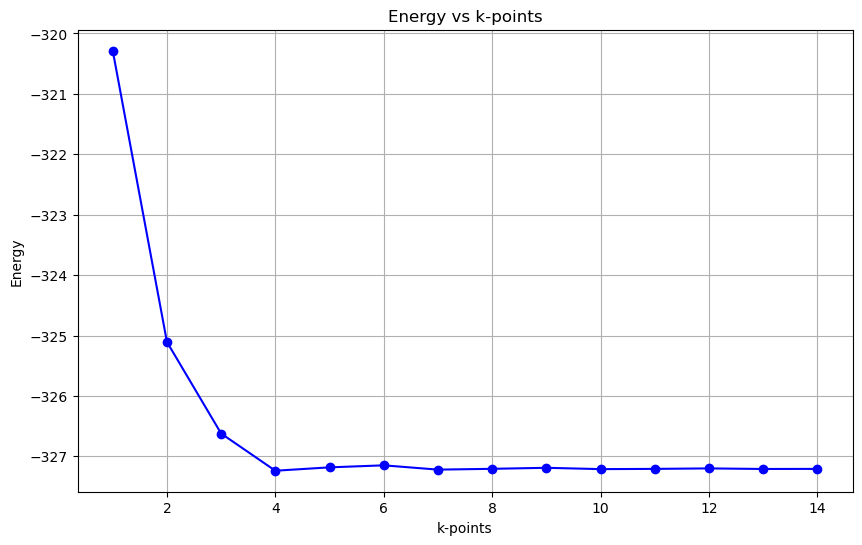

In [15]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.siesta import Siesta
import os
from ase.units import Ry
import numpy as np
import matplotlib.pyplot as plt

os.mkdir("gr_siesta_kpts")
os.chdir("gr_siesta_kpts")

# Build graphene with total 8 Å vacuum along z
atoms = graphene(a=2.46, vacuum=8.0)
# Optional: center the sheet exactly in the cell along z
atoms.center(axis=2)

kk_array = []
energy_array = []

for kk in range(1, 15, 1): # loop over k-points from 1x1x1 to 8x8x8
 
    atoms.calc = Siesta(label='c2',
                            xc='PBE',
                            pseudo_path='../pseudopotentials/siesta',
                            pseudo_qualifier='gga',
                            symlink_pseudos=True,
                            mesh_cutoff=200 * Ry,
                            energy_shift=0.01 * Ry,
                            basis_set='DZP',
                            spin='non-polarized',
                            kpts=(kk, kk, 1),
                            fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 100},
                )
    energy = atoms.get_total_energy()
    print("k-points:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)

# Plot k-point energy convergence

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs k-points')  # Add a title to the plot
plt.xlabel('k-points')  # Label for the x-axis
plt.ylabel('Energy')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")

view(atoms, viewer='x3d')

Initial geometry of Ni on graphene

In [16]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.siesta import Siesta
import os
from ase.optimize.bfgs import BFGS
from ase.units import Ry
from ase import Atom
from ase.io import write

# Build graphene with total 8 Å vacuum along z
atoms = graphene(a=2.46, vacuum=8.0)
# Optional: center the sheet exactly in the cell along z
atoms.center(axis=2)

atoms = atoms.repeat((3,3,1))
atoms.append(Atom('Ni', (2.5, 1.5, 10.0)))

os.mkdir("gr1_siesta_opt")
os.chdir("gr1_siesta_opt")

atoms.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(3, 3, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 200},
               )

energy = atoms.get_total_energy()

opt = BFGS(atoms, trajectory='atoms.traj')
opt.run(fmax=0.03)

os.chdir("../")

write('gr1_siesta.traj', atoms)

view(atoms, viewer='x3d')

Job completed


      Step     Time          Energy          fmax
BFGS:    0 11:06:26    -7503.991448        3.959180


Job completed


BFGS:    1 11:06:39    -7504.260850        4.002311


Job completed


...

Job completed


BFGS:   16 11:09:20    -7505.467930        0.044358


Job completed


BFGS:   17 11:09:27    -7505.468194        0.040088
BFGS:   18 11:09:32    -7505.468341        0.023010


Job completed


Final geometry

In [17]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.siesta import Siesta
import os
from ase.optimize.bfgs import BFGS
from ase.units import Ry
from ase import Atom
from ase.io import write
from ase.io import read

atoms = read('gr1_siesta.traj')
mg_index = [i for i, a in enumerate(atoms) if a.symbol == 'Ni'][0]
dx = 1.5
dy = 2

atoms[mg_index].position += [dx, dy, 0.0]

os.mkdir("gr2_siesta_opt")
os.chdir("gr2_siesta_opt")

atoms.calc = Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(3, 3, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 200},
               )

energy = atoms.get_total_energy()

opt = BFGS(atoms, trajectory='atoms.traj')
opt.run(fmax=0.03)

os.chdir("../")

write('gr2_siesta.traj', atoms)

view(atoms, viewer='x3d')

Job completed


      Step     Time          Energy          fmax
BFGS:    0 11:09:56    -7505.101135        2.653580


Job completed


BFGS:    1 11:10:10    -7505.291190        1.264892


Job completed


...

Job completed


BFGS:   15 11:12:23    -7505.467441        0.078246


Job completed


BFGS:   16 11:12:30    -7505.468070        0.039566
BFGS:   17 11:12:38    -7505.468291        0.023695


Job completed


The NEB calculation proceeds by first reading the initial and final geometries and constructing a series of intermediate images using a linear interpolation algorithm. These images define the discrete points along the reaction pathway. Each image is then assigned its own SIESTA calculator so that forces and energies are evaluated consistently and independently. With the band fully defined, the NEB optimizer adjusts the images by removing the parallel component of the true force and adding spring forces along the path, gradually pushing the band toward the minimum‑energy pathway. Once the optimization converges, the code extracts the energies of all images, plots the NEB energy profile, and identifies the transition state as the image with the highest energy. Finally, the geometry of this transition‑state image is written out for visualization and further analysis, providing a complete picture of the reaction barrier and the atomic configuration at the saddle point.

Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed


Absolute energies (eV): [-7505.454213, -7505.080501, -7504.759845, -7505.079657, -7505.454245]
TS image index: 2
TS geometry saved as TS.traj


Job completed


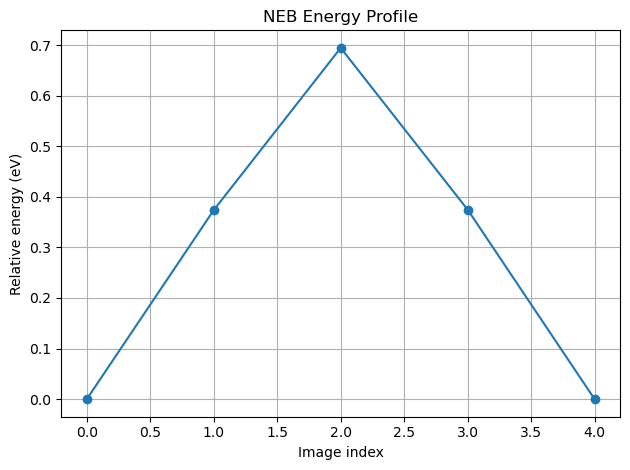

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os
from ase.io import read, write
from ase.mep import NEB
from ase.optimize import BFGS
from ase.calculators.siesta import Siesta
from ase.units import Ry
from ase.visualize import view


# ------------------------------------------------------------
# 1. Read initial and final geometries
# ------------------------------------------------------------
initial = read('gr1_siesta.traj')   # or initial.xyz / initial.traj
final   = read('gr2_siesta.traj')

os.mkdir("neb_siesta")
os.chdir("neb_siesta")

# ------------------------------------------------------------
# 2. Create NEB images (initial + 3 intermediates + final)
# ------------------------------------------------------------
n_images = 5
images = [initial]

for i in range(n_images - 2):
    images.append(initial.copy())

images.append(final)

neb = NEB(images)
neb.interpolate()   # linear interpolation

# ------------------------------------------------------------
# 3. Attach a *separate* SIESTA calculator to each image
# ------------------------------------------------------------
def make_siesta_calc(label):
    return Siesta(label='c2',
                        xc='PBE',
                        pseudo_path='../pseudopotentials/siesta',
                        pseudo_qualifier='gga',
                        symlink_pseudos=True,
                        mesh_cutoff=230 * Ry,
                        energy_shift=0.01 * Ry,
                        basis_set='DZP',
                        spin='non-polarized',
                        kpts=(3, 3, 1),
                        fdf_arguments={'DM.MixingWeight': 0.1, 'MaxSCFIterations': 200},
               )


for i, img in enumerate(images):
    img.calc = make_siesta_calc(f'neb_img_{i}')

# ------------------------------------------------------------
# 4. Optimize the NEB path
# ------------------------------------------------------------
opt = BFGS(neb, logfile='neb.log')
opt.run(fmax=0.05)  # convergence criterion for forces on images

# ------------------------------------------------------------
# 5. Collect energies and compute relative profile
# ------------------------------------------------------------
energies = [img.get_potential_energy() for img in images]
E0 = energies[0]
rel_energies = [E - E0 for E in energies]

# Identify TS (highest energy image)
ts_index = int(np.argmax(energies))
ts_image = images[ts_index]
write('TS.traj', ts_image)

os.chdir("../")

# ------------------------------------------------------------
# 6. Plot NEB energy profile
# ------------------------------------------------------------
plt.figure()
plt.plot(range(n_images), rel_energies, '-o')
plt.xlabel('Image index')
plt.ylabel('Relative energy (eV)')
plt.title('NEB Energy Profile')
plt.grid(True)
plt.tight_layout()
plt.savefig('neb_profile.png', dpi=200)

print("Absolute energies (eV):", energies)
print("TS image index:", ts_index)
print("TS geometry saved as TS.traj")

view(ts_image, viewer='x3d')

II. Quantum ESPRESSO

Quantum ESPRESSO (QE) is an open‑source suite of plane‑wave Density Functional Theory (DFT) codes designed for electronic‑structure calculations and materials modeling. Unlike LCAO‑based codes such as SIESTA, QE uses plane‑wave basis sets together with pseudopotentials, making it particularly well suited for periodic systems, crystalline materials, and simulations requiring systematic convergence with respect to basis‑set size.

Because plane waves form a complete and unbiased basis, QE offers high numerical accuracy and predictable convergence behavior. This makes it a popular choice for studying band structures, phonons, dielectric properties, and many other phenomena where precision is essential. QE also supports a wide range of pseudopotential formats, including norm‑conserving, ultrasoft, and PAW datasets, giving users flexibility in balancing accuracy and computational cost.

The code is parallelized efficiently using MPI and OpenMP, enabling large‑scale simulations on modern HPC systems. Its active development community continuously expands its capabilities, integrates new methods, and maintains a rich ecosystem of tools for pre‑ and post‑processing.

Overall, Quantum ESPRESSO provides a robust, versatile, and widely adopted platform for first‑principles materials modeling, complementing LCAO‑based codes and offering a different set of strengths for high‑accuracy plane‑wave calculations.

1. A single‑point calculation performed with Quantum ESPRESSO introduces the essential structure of a QE workflow: defining the atomic system, selecting the plane‑wave cutoff energies and pseudopotentials, configuring the pw.x input parameters, and executing the self‑consistent field (SCF) cycle to obtain the electronic ground‑state properties without performing any geometry optimization.

In [19]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.build import bulk
from ase.visualize import view
profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)


os.mkdir("c2_qe")
os.chdir("c2_qe")

a = 3.567  # lattice constant in Å

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

# Minimal Quantum Espresso calculator for testing
atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe'        # ← THIS is the QE system label
            },
            'system': {
                'ecutwfc': 30,
                'ecutrho': 105
            },
            'electrons': {
                'conv_thr': 1e-8
            }
        },
        kpts=(4, 4, 4)
    )

energy = atoms.get_total_energy()

# Run a single-point calculation

os.chdir("../")

print("Energy:", energy)

view(atoms, viewer='x3d')

Energy: -2006.1763141688782


2. Converging the k‑point mesh in Quantum ESPRESSO is essential for obtaining reliable and reproducible plane‑wave DFT results. Because QE samples the Brillouin zone using a discrete grid, the accuracy of total energies, forces, and electronic properties depends directly on the density of this k‑point sampling. The required mesh is determined by the Bravais lattice and the reciprocal‑space dimensions of the periodic cell: large real‑space cells require fewer k‑points, while compact cells demand a denser grid. As in SIESTA, the optimal k‑point mesh is unique to each system and cannot be transferred from another calculation. The standard procedure is to systematically increase the k‑point density and monitor the convergence of the total energy (and, when needed, forces or stress). Only once the energy changes fall below a chosen threshold can the mesh be considered converged, ensuring that subsequent geometry optimizations, band‑structure calculations, and DOS analyses are built on a solid numerical foundation.

k-points: 1
Energy: -1990.2555454531594
k-points: 2
Energy: -2005.4408884239738
k-points: 3
Energy: -2006.11167951301
k-points: 4
Energy: -2006.1763141688782
k-points: 5
Energy: -2006.174496448436
k-points: 6
Energy: -2006.1830646329308
k-points: 7
Energy: -2006.1818145419559
k-points: 8
Energy: -2006.1709278114988


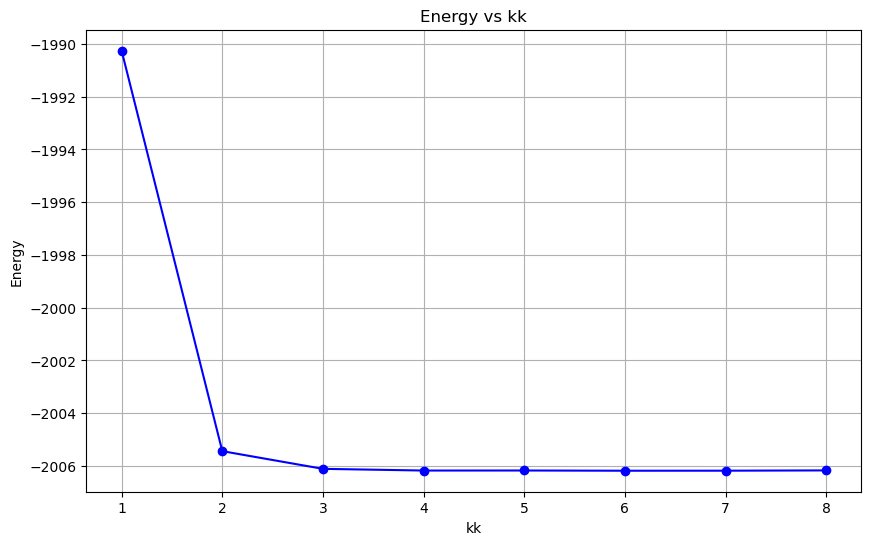

In [20]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.build import bulk
import numpy as np
import matplotlib.pyplot as plt
profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

os.mkdir("c2_qe_kpts")
os.chdir("c2_qe_kpts")

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

kk_array = []
energy_array = []


for kk in range(1, 9, 1):
    atoms.calc = Espresso(
            pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
            profile=profile,
            input_data={
                'control': {
                    'calculation': 'scf',
                    'prefix': 'c2_qe'        # ← THIS is the QE system label
                },
                'system': {
                    'ecutwfc': 30,
                    'ecutrho': 105
                },
                'electrons': {
                    'conv_thr': 1e-8
                }
            },
            kpts=(kk, kk, kk)
        )
    energy = atoms.get_total_energy()
    print("k-points:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)

# Run a single-point calculation

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs kk')  # Add a title to the plot
plt.xlabel('kk')  # Label for the x-axis
plt.ylabel('Energy')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")


3. In Quantum ESPRESSO, converging the plane‑wave cutoff energies is essential for obtaining accurate and reproducible results. QE uses two separate cutoffs: ecutwfc for the Kohn–Sham wavefunctions and ecutrho for the charge density. Because the charge density contains products of wavefunctions, it requires a much larger basis set—typically four times the wavefunction cutoff for norm‑conserving pseudopotentials, and 8–12× for ultrasoft or PAW datasets. These cutoffs determine how many plane waves are included in the expansion, directly affecting the precision of total energies, forces, stresses, and electronic properties. The required values depend strongly on the pseudopotential and cannot be transferred from another system. Therefore, the standard procedure is to systematically increase ecutwfc (and the corresponding ecutrho) until the total energy and forces change by less than a chosen threshold. Only after this convergence is achieved can subsequent geometry optimizations, DOS calculations, and phonon simulations be considered numerically reliable.

cutoff: 30
Energy: -2005.7037156976007
cutoff: 35
Energy: -2006.2291408528886
cutoff: 40
Energy: -2006.377217176527
cutoff: 45
Energy: -2006.410393023622
cutoff: 50
Energy: -2006.4166002123955
cutoff: 55
Energy: -2006.423694764397
cutoff: 60
Energy: -2006.4395326061483
cutoff: 65
Energy: -2006.4481402471495
cutoff: 70
Energy: -2006.4561443396567
cutoff: 75
Energy: -2006.4615377719958
cutoff: 80
Energy: -2006.4642134673713
cutoff: 85
Energy: -2006.4655819278657
cutoff: 90
Energy: -2006.4652465475594


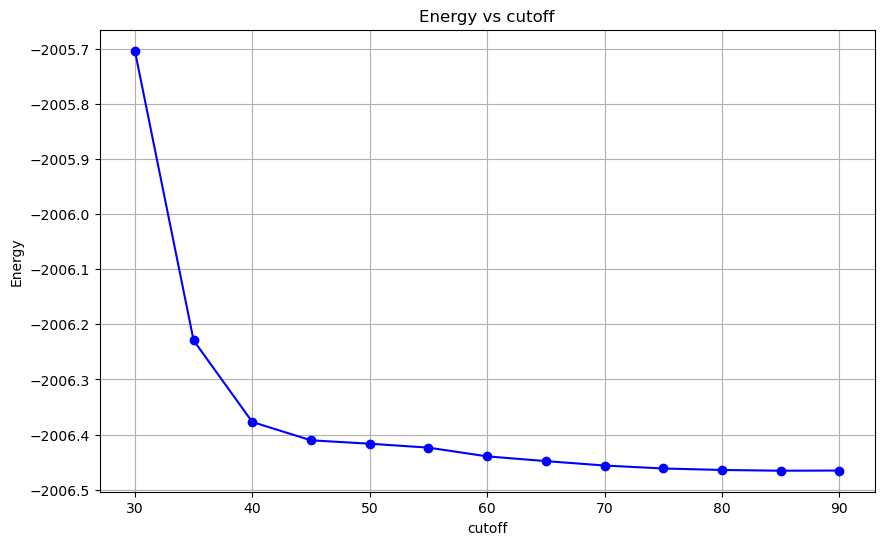

In [21]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.build import bulk
import numpy as np
import matplotlib.pyplot as plt
profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

os.mkdir("c2_qe_cutoff")
os.chdir("c2_qe_cutoff")

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

kk_array = []
energy_array = []


for kk in range(30, 95, 5):
    atoms.calc = Espresso(
            pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
            profile=profile,
            input_data={
                'control': {
                    'calculation': 'scf',
                    'prefix': 'c2_qe'        # ← THIS is the QE system label
                },
                'system': {
                    'ecutwfc': kk,
                    'ecutrho': 4*kk
                },
                'electrons': {
                    'conv_thr': 1e-8
                }
            },
            kpts=(5, 5, 5)
        )
    energy = atoms.get_total_energy()
    print("cutoff:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)

# Run a single-point calculation

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs cutoff')  # Add a title to the plot
plt.xlabel('cutoff')  # Label for the x-axis
plt.ylabel('Energy')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")


4. Geometry and lattice optimization in this tutorial are performed using the ASE optimization algorithms, while Quantum ESPRESSO serves strictly as the force and energy calculator. This separation of roles is intentional. Although QE provides built‑in relaxation modes, external frameworks such as ASE offer modern, robust, and flexible optimization algorithms that integrate naturally with Python workflows and often provide smoother convergence for both atomic positions and cell degrees of freedom. The optimizer used here is the Broyden–Fletcher–Goldfarb–Shanno (BFGS) algorithm, a quasi‑Newton method that combines gradient information with an evolving approximation of the inverse Hessian. This approach accelerates convergence by effectively estimating the curvature of the energy landscape without requiring explicit second‑derivative calculations. In contrast, QE’s internal Conjugate Gradient (CG) relaxations rely solely on first‑order information. CG constructs search directions that are conjugate with respect to the Hessian but never stores or approximates the Hessian itself. While efficient and widely used, CG typically converges more slowly and less smoothly than quasi‑Newton methods, especially for complex materials or systems with soft vibrational modes. To enable full lattice optimization, ASE provides the UnitCellFilter class, which exposes the cell degrees of freedom to the optimizer. When wrapped around the atomic configuration, UnitCellFilter ensures that both atomic positions and lattice vectors are updated consistently during the optimization process, allowing QE to supply accurate forces and stresses while ASE handles the optimization logic.

In [22]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.build import bulk
from ase.visualize import view
from ase.optimize.bfgs import BFGS
from ase.filters import UnitCellFilter

from ase.io import write


profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)


os.mkdir("c2_qe_opt")
os.chdir("c2_qe_opt")

atoms = bulk('C', 'diamond', a=3.567, cubic=True)

print("Initial cell:")
print(atoms.cell)

# Minimal Quantum Espresso calculator for testing
atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80
            },
            'electrons': {
                'conv_thr': 1e-8
            }
        },
        kpts=(5, 5, 5)
    )

energy = atoms.get_total_energy()

ucf = UnitCellFilter(atoms)
opt = BFGS(ucf, trajectory='cellopt.traj')
opt.run(fmax=0.01)

# Run a single-point calculation

os.chdir("../")

print("Final cell:")
print(atoms.cell)

write('cell_qe.traj', atoms)

view(atoms, viewer='x3d')

Initial cell:
Cell([3.567, 3.567, 3.567])
      Step     Time          Energy          fmax
BFGS:    0 11:27:59    -2006.464213        0.077772
BFGS:    1 11:28:03    -2006.464471        0.071245
BFGS:    2 11:28:06    -2006.465847        0.000747
Final cell:
Cell([[3.5729021519792807, -1.0342775343076179e-21, 0.0], [3.279736196116198e-22, 3.5729021519792807, 0.0], [1.3292301722414569e-21, 0.0, 3.5729021519792807]])


5. The Density of States (DOS) is one of the fundamental electronic properties computed in Density Functional Theory. It describes how many electronic states are available at each energy level and provides direct insight into the material’s electronic behavior. By examining the DOS, we can identify the valence band, conduction band, and the band gap, which together determine whether a material behaves as an insulator, semiconductor, or metal. Because of this, DOS analysis is an essential step in interpreting and understanding the electronic structure obtained from DFT calculations.

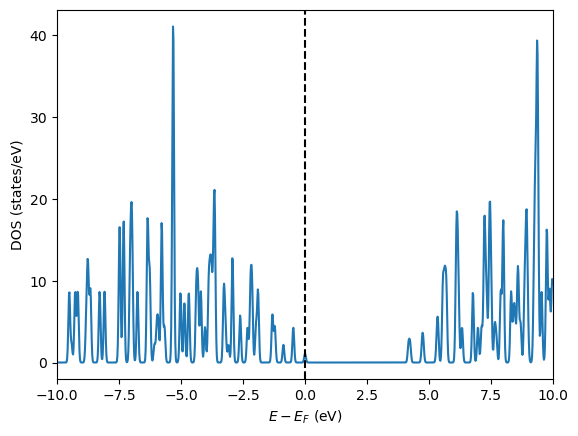

In [23]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.io import read
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

atoms = read('cell_qe.traj')
atoms.pbc=True

os.mkdir("c2_qe_dos")
os.chdir("c2_qe_dos")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
                'nbnd': 48
            },
            'electrons': {
                'conv_thr': 1e-8
            }
        },
        kpts=(5, 5, 5)
    )

energy = atoms.get_potential_energy()

dos = DOS(atoms.calc,
          width=0.05,
          npts=3000)

E = dos.get_energies()
D = dos.get_dos()

os.chdir("../")

# Select only -10 to +10 eV around Ef
mask = (E >= -10) & (E <= 10)

plt.plot(E[mask], D[mask])
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-10, 10)
plt.xlabel(r'$E - E_F$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.show()


6. Surface with QE

In [2]:
from ase import Atoms
from ase.build import surface
from ase.visualize import view
from ase.io import read
from ase.io import write
import os
from ase.optimize.bfgs import BFGS
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.optimize.bfgs import BFGS

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

slab = read('slab_siesta.traj')
slab.pbc=True

# center slab in vacuum
slab.center(axis=2)

os.mkdir("c2_qe_slab_opt")
os.chdir("c2_qe_slab_opt")

# Minimal Vasp calculator for testing
slab.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
                'assume_isolated':'2D'
            },
            'electrons': {
                'mixing_beta': 0.1,
                'electron_maxstep': 300,
                'conv_thr': 1e-6
            }
        },
        kpts=(5, 5, 1)
    )


energy = slab.get_total_energy()

opt = BFGS(slab, trajectory='cellopt.traj')
opt.run(fmax=0.03)

# Run a single-point calculation

os.chdir("../")

write('slab_qe.traj', slab)

view(slab, viewer='x3d')

      Step     Time          Energy          fmax
BFGS:    0 13:48:42    -3999.340472        0.551566
BFGS:    1 13:52:43    -3999.355129        0.297012
BFGS:    2 13:58:01    -3999.361416        0.169654
BFGS:    3 14:00:00    -3999.364261        0.176526
BFGS:    4 14:02:18    -3999.369446        0.106763
BFGS:    5 14:04:24    -3999.371002        0.050799
BFGS:    6 14:09:00    -3999.371300        0.010603


7. The surface Density of States (DOS) provides essential insight into how a surface modifies the electronic structure of a material. Unlike the bulk, where all bonds are fully coordinated, a surface exposes atoms with unsatisfied valence—leading to electronic features that can differ dramatically from the bulk behavior. The DOS of the diamond (100) surface illustrates this clearly. Although bulk diamond is a wide‑band‑gap insulator, the (100) surface shows no band gap and exhibits metallic character. At first glance this result may seem counterintuitive. However, the explanation lies in the orbital configuration of the surface atoms. The top‑layer carbon atoms possess dangling bonds that are not compensated by neighboring atoms. These dangling‑bond states fall within the band gap of bulk diamond and create partially filled surface states, giving rise to metallic behavior. This metallicity is not just a computational artifact—it is consistent with experimental observations, where clean diamond surfaces often display surface conductivity due to these unsaturated bonds. Understanding this effect is crucial when studying surface chemistry, adsorption, catalysis, or electronic devices based on diamond surfaces.

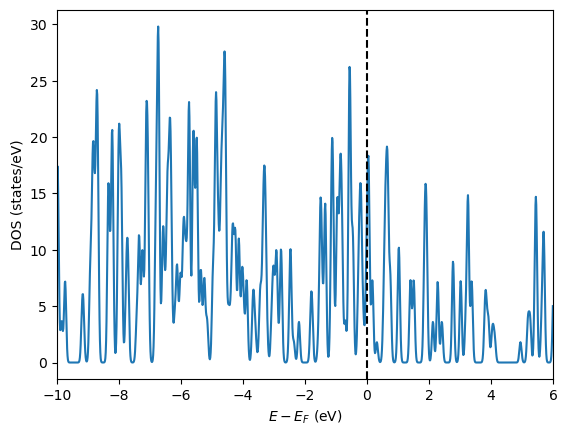

In [2]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.io import read
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

atoms = read('slab_qe.traj')
atoms.pbc=True

os.mkdir("c2_qe_slab_dos")
os.chdir("c2_qe_slab_dos")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
                'occupations': 'smearing',
                'smearing': 'mv',
                'degauss': 0.02,
                # no nspin, no starting_magnetization → non‑polarized
                'assume_isolated': '2D',
                'nbnd': 70
                
            },
            'electrons': {
                'conv_thr': 1e-6,
                'electron_maxstep': 500,
                'mixing_mode': 'local-TF',
                'mixing_beta': 0.2,
                'mixing_ndim': 8,
            }
        },
        kpts=(5, 5, 1)
    )

energy = atoms.get_potential_energy()

dos = DOS(atoms.calc,
          width=0.05,
          npts=3000)

E = dos.get_energies()
D = dos.get_dos()

os.chdir("../")

# Select only -10 to +10 eV around Ef
mask = (E >= -10) & (E <= 6)

plt.plot(E[mask], D[mask])
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-10, 6)
plt.xlabel(r'$E - E_F$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.show()


8. To hydrogen‑passivate the surface, we begin by reading the optimized slab obtained from the SIESTA calculations and extract only the positions of the hydrogen atoms. These hydrogen coordinates are then added to the unpassivated slab optimized with Quantum ESPRESSO, ensuring that the passivation pattern is physically meaningful while keeping the underlying lattice consistent with the QE calculation.

In [2]:
from ase.visualize import view
from ase.io import read
from ase.io import write
import os
from ase.optimize.bfgs import BFGS
from ase.calculators.espresso import Espresso, EspressoProfile

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

atoms2_with_H = read('slab_h_siesta_high.traj')
atoms2_with_H.pbc = True

os.mkdir("c2_qe_h_qe_high_opt")
os.chdir("c2_qe_h_qe_high_opt")

# Minimal Vasp calculator for testing
atoms2_with_H.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF', 'H': 'H.pbe-rrkjus_psl.1.0.0.UPF '},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80
            },
            'electrons': {
                'mixing_beta': 0.3,
                'electron_maxstep': 300,
                'conv_thr': 1e-6
            }
        },
        kpts=(5, 5, 1)
    )

energy = atoms2_with_H.get_total_energy()

opt = BFGS(atoms2_with_H, trajectory='cellopt.traj')
opt.run(fmax=0.03)

# Run a single-point calculation

os.chdir("../")

write('slab_h_qe_high.traj', atoms2_with_H)

view(atoms2_with_H, viewer='x3d')

      Step     Time          Energy          fmax
BFGS:    0 19:18:00    -4135.628782        0.588908
BFGS:    1 19:18:32    -4135.647460        0.219265
BFGS:    2 19:19:04    -4135.652244        0.165810
BFGS:    3 19:19:36    -4135.658116        0.127702
BFGS:    4 19:20:09    -4135.660426        0.122842
BFGS:    5 19:20:41    -4135.664749        0.095589
BFGS:    6 19:21:14    -4135.666620        0.073378
BFGS:    7 19:21:46    -4135.667601        0.047721
BFGS:    8 19:22:19    -4135.668151        0.037247
BFGS:    9 19:22:52    -4135.668694        0.034475
BFGS:   10 19:23:25    -4135.669022        0.031088
BFGS:   11 19:23:59    -4135.669196        0.021516


9. The Density of States (DOS) of the hydrogen‑passivated diamond (100) surface shows a large band gap, closely matching that of bulk diamond. This behavior is expected: once the surface carbon atoms are saturated with hydrogen, the dangling‑bond states responsible for the metallic character of the pristine surface are removed. With these mid‑gap states eliminated, the electronic structure of the slab returns to that of an insulator, demonstrating that hydrogen termination effectively restores the bulk‑like electronic properties at the surface.

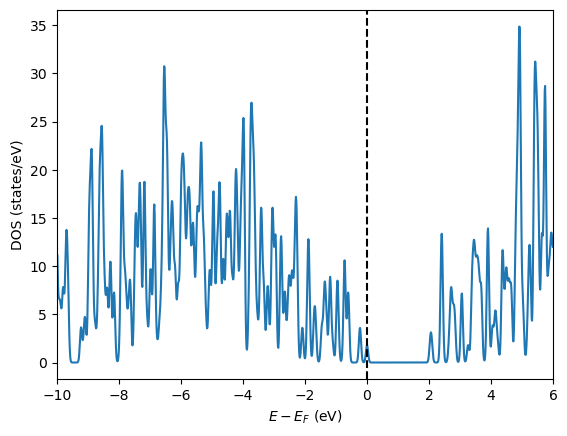

In [3]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.io import read
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

atoms = read('slab_h_qe_high.traj')
atoms.pbc=True

os.mkdir("c2_qe_slab_h_dos_high")
os.chdir("c2_qe_slab_h_dos_high")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF', 'H': 'H.pbe-rrkjus_psl.1.0.0.UPF '},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
                'nbnd': 70
            },
            'electrons': {
                'conv_thr': 1e-6
            }
        },
        kpts=(5, 5, 1)
    )

energy = atoms.get_potential_energy()

dos = DOS(atoms.calc,
          width=0.05,
          npts=3000)

E = dos.get_energies()
D = dos.get_dos()

os.chdir("../")

# Select only -10 to +10 eV around Ef
mask = (E >= -10) & (E <= 6)

plt.plot(E[mask], D[mask])
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-10, 6)
plt.xlabel(r'$E - E_F$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.show()


10. The Density of States (DOS) tells us how electronic states are distributed relative to the Fermi level, but it does not provide the absolute energy of the Fermi level. In periodic DFT calculations, all eigenvalues are referenced to an arbitrary internal zero, determined by the basis set, pseudopotentials, and numerical setup. As a result, absolute energy levels cannot be compared directly between two different materials or even between two separate calculations of the same material using different computational parameters. To obtain meaningful, comparable energy references, we compute the work function or, more precisely, the ionization potential of the slab. This quantity gives the energy of the valence‑band maximum (VBM) relative to the vacuum level, which is the same physical reference for every slab. By anchoring the electronic structure to the vacuum level, we can compare band edges, Fermi levels, and work functions across different systems in a consistent way. To perform work‑function or ionization‑potential calculations, the slab must include a sufficiently thick vacuum region. The electrostatic potential must reach a flat plateau in the vacuum, indicating that the potential is constant and free from interactions with the slab. Once this plateau is identified, we extract the vacuum electrostatic potential and reference the VBM (or Fermi level) to it. QE outputs the electrostatic potential in the file potential.cube, which contains the volumetric data needed to compute the averaged potential along the slab normal, allowing post‑processing tools (such as ASE or custom Python scripts) to compute the work function accurately.

Created pp.in

Vacuum level :   4.746656 eV
VBM          :   1.777800 eV
-----------------------------------
IP = Evac-VBM:   2.968856 eV


Note: The following floating-point exceptions are signalling: IEEE_OVERFLOW_FLAG


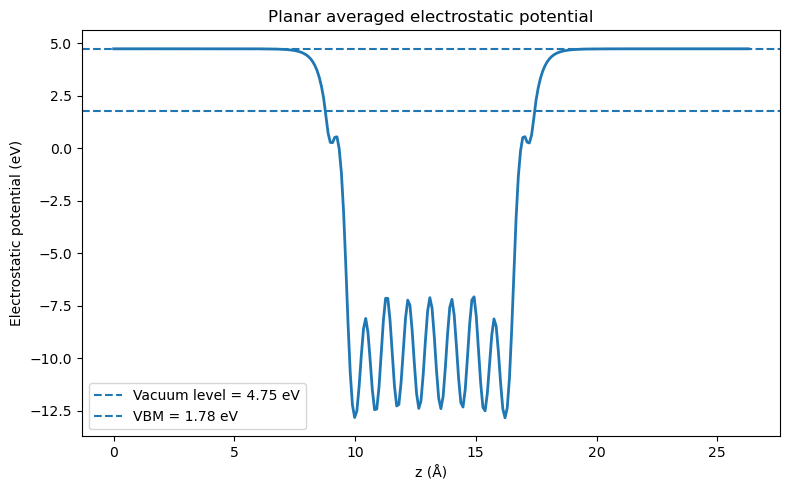

In [2]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from ase.io.cube import read_cube_data

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

prefix = "c2_qe"
outdir = "."

atoms = read('slab_h_qe_high.traj')
atoms.pbc=True

os.mkdir("c2_qe_slab_h_WF")
os.chdir("c2_qe_slab_h_WF")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF', 'H': 'H.pbe-rrkjus_psl.1.0.0.UPF '},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4 * 80,
            },
            'electrons': {
                'conv_thr': 1e-6
            }
        },
        kpts=(5, 5, 1)
    )

energy = atoms.get_potential_energy()

pp_input = f"""&INPUTPP
    prefix='{prefix}'
    outdir='{outdir}'
    filplot='potential'
    plot_num=11
/

&PLOT
    nfile=1
    filepp(1)='potential'
    iflag=3
    output_format=6
    fileout='potential.cube'
/
"""

with open("pp.in", "w") as f:
    f.write(pp_input)

print("Created pp.in")

os.system("pp.x < pp.in > pp.out")

# ==========================================================
# Read electrostatic potential from QE pp.x cube file
# ==========================================================

data, atoms = read_cube_data("potential.cube")

# QE usually writes potentials in Ry
RY_TO_EV = 13.605693

# convert to eV
data *= RY_TO_EV

# planar average
V_z = data.mean(axis=(0, 1))

# z coordinate
z = np.linspace(
    0,
    atoms.cell[2, 2],
    data.shape[2]
)

# vacuum level
V_vac = np.max(V_z)

# ==========================================================
# Read VBM from QE output
# ==========================================================

VBM = None

with open("espresso.pwo") as f:
    for line in f:
        if "highest occupied level" in line.lower():
            VBM = float(line.split()[-1])
            break

if VBM is None:
    raise RuntimeError(
        "Could not find 'highest occupied level' in espresso.pwo"
    )

# ==========================================================
# Ionization potential
# ==========================================================

IP = V_vac - VBM

print()
print("===================================")
print(f"Vacuum level : {V_vac:10.6f} eV")
print(f"VBM          : {VBM:10.6f} eV")
print("-----------------------------------")
print(f"IP = Evac-VBM: {IP:10.6f} eV")
print("===================================")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(z, V_z, lw=2)

plt.axhline(
    V_vac,
    linestyle='--',
    label=f'Vacuum level = {V_vac:.2f} eV'
)

plt.axhline(
    VBM,
    linestyle='--',
    label=f'VBM = {VBM:.2f} eV'
)

plt.xlabel("z (Å)")
plt.ylabel("Electrostatic potential (eV)")
plt.title("Planar averaged electrostatic potential")
plt.legend()

plt.tight_layout()
plt.show()


os.chdir("../")



The ionization potential of the hydrogen‑passivated diamond (100) slab is calculated to be 2.968856 eV, whereas the pristine diamond (100) surface exhibits a much higher value of 7.172100 eV. This dramatic difference is well‑known experimentally and highlights the crucial role of surface reconstruction and surface termination in determining electronic properties.

Hydrogen termination fundamentally alters the surface electronic environment. By saturating the dangling bonds on the topmost carbon atoms, hydrogen atoms create a surface dipole layer that shifts the electrostatic potential downward. This dipole makes it energetically easier to remove an electron from the surface, resulting in a much lower ionization potential. In practical terms, the H‑terminated surface becomes far more favorable for electron emission, a property exploited in applications such as negative‑electron‑affinity (NEA) diamond devices.

In contrast, the pristine diamond (100) surface lacks these stabilizing dipoles. Its unsaturated dangling bonds produce mid‑gap states and a higher surface potential, making electron extraction significantly more difficult. The high ionization potential reflects this unfavorable electronic environment.

These results demonstrate how surface chemistry directly controls the electronic structure, and they emphasize the importance of accurate surface modeling when studying real materials or designing diamond‑based electronic and optoelectronic devices.

Created pp.in

Vacuum level :   5.586500 eV
VBM          :  -1.585600 eV
-----------------------------------
IP = Evac-VBM:   7.172100 eV


Note: The following floating-point exceptions are signalling: IEEE_OVERFLOW_FLAG


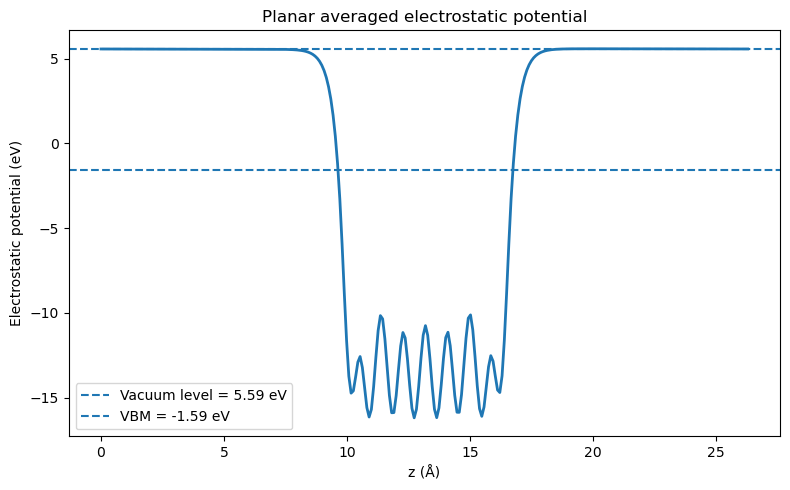

In [3]:
from ase import Atoms
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from ase.io.cube import read_cube_data


profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

prefix = "c2_qe"
outdir = "."

atoms = read('slab_qe.traj')
atoms.pbc=True

os.mkdir("c2_qe_slab_WF")
os.chdir("c2_qe_slab_WF")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
            },
            'electrons': {
                'conv_thr': 1e-6,
                'electron_maxstep': 300
            }
        },
        kpts=(5, 5, 1)
    )

energy = atoms.get_potential_energy()

pp_input = f"""&INPUTPP
    prefix='{prefix}'
    outdir='{outdir}'
    filplot='potential'
    plot_num=11
/

&PLOT
    nfile=1
    filepp(1)='potential'
    iflag=3
    output_format=6
    fileout='potential.cube'
/
"""

with open("pp.in", "w") as f:
    f.write(pp_input)

print("Created pp.in")

os.system("pp.x < pp.in > pp.out")

# ==========================================================
# Read electrostatic potential from QE pp.x cube file
# ==========================================================

data, atoms = read_cube_data("potential.cube")

# QE usually writes potentials in Ry
RY_TO_EV = 13.605693

# convert to eV
data *= RY_TO_EV

# planar average
V_z = data.mean(axis=(0, 1))

# z coordinate
z = np.linspace(
    0,
    atoms.cell[2, 2],
    data.shape[2]
)

# vacuum level
V_vac = np.max(V_z)

# ==========================================================
# Read VBM from QE output
# ==========================================================

VBM = None

with open("espresso.pwo") as f:
    for line in f:
        if "highest occupied level" in line.lower():
            VBM = float(line.split()[-1])
            break

if VBM is None:
    raise RuntimeError(
        "Could not find 'highest occupied level' in espresso.pwo"
    )

# ==========================================================
# Ionization potential
# ==========================================================

IP = V_vac - VBM

print()
print("===================================")
print(f"Vacuum level : {V_vac:10.6f} eV")
print(f"VBM          : {VBM:10.6f} eV")
print("-----------------------------------")
print(f"IP = Evac-VBM: {IP:10.6f} eV")
print("===================================")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(z, V_z, lw=2)

plt.axhline(
    V_vac,
    linestyle='--',
    label=f'Vacuum level = {V_vac:.2f} eV'
)

plt.axhline(
    VBM,
    linestyle='--',
    label=f'VBM = {VBM:.2f} eV'
)

plt.xlabel("z (Å)")
plt.ylabel("Electrostatic potential (eV)")
plt.title("Planar averaged electrostatic potential")
plt.legend()

plt.tight_layout()
plt.show()


os.chdir("../")



In this tutorial we compared the performance and results of SIESTA and Quantum ESPRESSO for bulk and slab calculations. Despite their methodological differences—LCAO basis sets versus plane waves—both approaches produced consistent and physically meaningful results, including similar lattice parameters, electronic structures, and work‑function trends. SIESTA exhibited occasional SCF convergence difficulties for certain geometries, particularly highly distorted slabs, but once stabilized it remained reliable. In terms of computational efficiency, SIESTA was typically an order of magnitude faster for slab systems, making it attractive for large‑scale or exploratory studies. QE, on the other hand, offers systematic convergence, robust plane‑wave accuracy, and excellent reproducibility, which can be crucial for high‑precision electronic‑structure work. Ultimately, the choice between the two methods depends on the system size, the desired level of accuracy, and the available computational resources, with both codes providing complementary strengths for modern materials‑science workflows.

11. NEB with QE

k-points: 1
Energy: -495.0376279486487
k-points: 2
Energy: -499.76308190338017
k-points: 3
Energy: -501.31089943188334
k-points: 4
Energy: -501.9183760253395
k-points: 5
Energy: -501.8611349745814
k-points: 6
Energy: -501.82853410402737
k-points: 7
Energy: -501.89906941242987
k-points: 8
Energy: -501.88556617135737
k-points: 9
Energy: -501.86891552557006
k-points: 10
Energy: -501.8906825918087
k-points: 11
Energy: -501.8867106821628
k-points: 12
Energy: -501.87880863234517
k-points: 13
Energy: -501.8882205057966
k-points: 14
Energy: -501.8866890491126


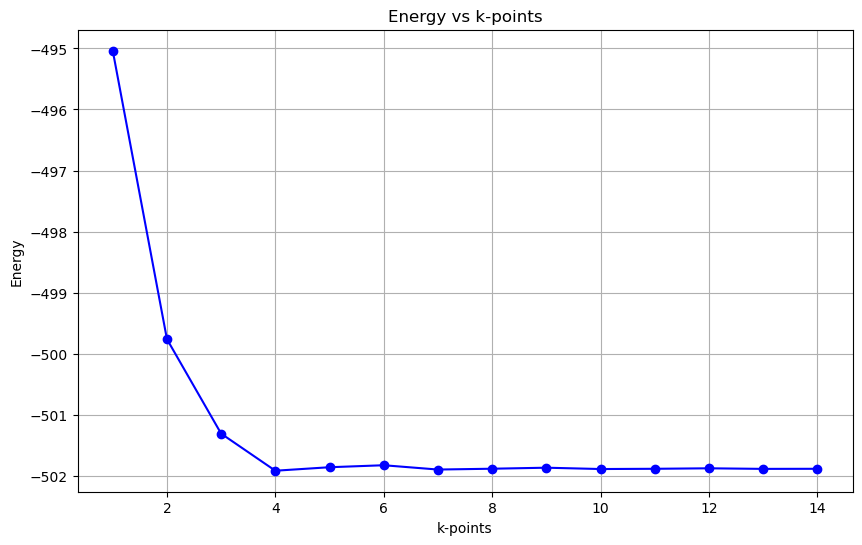

In [4]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.espresso import Espresso, EspressoProfile
import os
import numpy as np
import matplotlib.pyplot as plt

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

os.mkdir("gr_qe_kpts")
os.chdir("gr_qe_kpts")

# Build graphene with total 8 Å vacuum along z
atoms = graphene(a=2.46, vacuum=8.0)
# Optional: center the sheet exactly in the cell along z
atoms.center(axis=2)

kk_array = []
energy_array = []

for kk in range(1, 15, 1): # loop over k-points from 1x1x1 to 8x8x8
 
    atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe'
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
            },
            'electrons': {
                'conv_thr': 1e-8,
                'electron_maxstep': 200
            }
        },
        kpts=(kk, kk, 1)
    )
    energy = atoms.get_total_energy()
    print("k-points:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)

# Plot k-point energy convergence

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs k-points')  # Add a title to the plot
plt.xlabel('k-points')  # Label for the x-axis
plt.ylabel('Energy')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")

view(atoms, viewer='x3d')

cutoff: 30
Energy: -501.7729992070377
cutoff: 35
Energy: -501.8329433006121
cutoff: 40
Energy: -501.8572181679878
cutoff: 45
Energy: -501.87001935535653
cutoff: 50
Energy: -501.8722585801349
cutoff: 55
Energy: -501.8727045747164
cutoff: 60
Energy: -501.87383860913906
cutoff: 65
Energy: -501.87575782804305
cutoff: 70
Energy: -501.87704791975216
cutoff: 75
Energy: -501.878063448598
cutoff: 80
Energy: -501.87880863234517
cutoff: 85
Energy: -501.8791449650497
cutoff: 90
Energy: -501.87944156913386


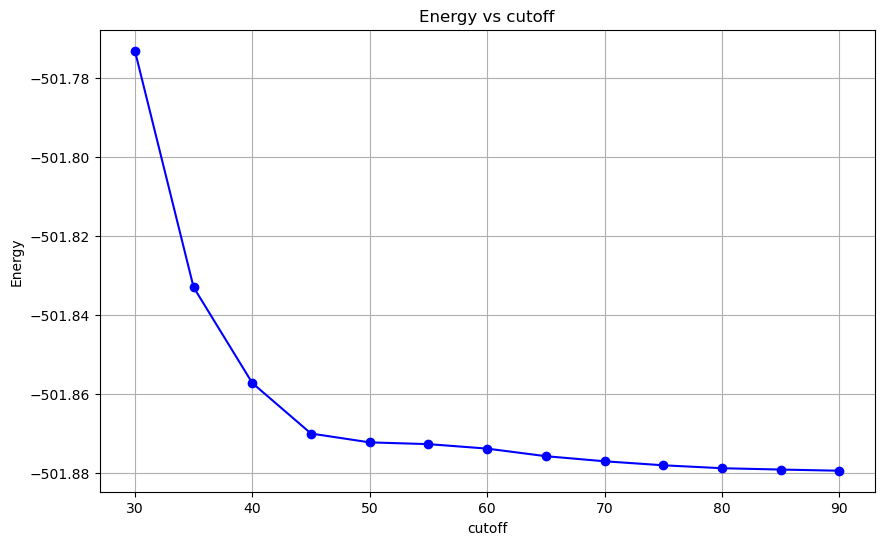

In [5]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.espresso import Espresso, EspressoProfile
import os
import numpy as np
import matplotlib.pyplot as plt

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

os.mkdir("gr_qe_cutoff")
os.chdir("gr_qe_cutoff")

# Build graphene with total 8 Å vacuum along z
atoms = graphene(a=2.46, vacuum=8.0)
# Optional: center the sheet exactly in the cell along z
atoms.center(axis=2)

kk_array = []
energy_array = []

for kk in range(30, 91, 5): 
 
    atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe'
            },
            'system': {
                'ecutwfc': kk,
                'ecutrho': 4*kk,
            },
            'electrons': {
                'conv_thr': 1e-8,
                'electron_maxstep': 200
            }
        },
        kpts=(12, 12, 1)
    )
    energy = atoms.get_total_energy()
    print("cutoff:", kk)
    kk_array.append(kk)
    print("Energy:", energy)
    energy_array.append(energy)

# Plot cutoff energy convergence

plt.figure(figsize=(10, 6))  # Set the figure size (optional)
plt.plot(kk_array, energy_array, marker='o', linestyle='-', color='b')  # Plot the data
plt.title('Energy vs cutoff')  # Add a title to the plot
plt.xlabel('cutoff')  # Label for the x-axis
plt.ylabel('Energy')  # Label for the y-axis
plt.grid(True)  # Add a grid (optional)
plt.show()  # Display the plot

os.chdir("../")

view(atoms, viewer='x3d')

In [2]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.optimize.bfgs import BFGS
from ase import Atom
from ase.io import write

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

# Build graphene with total 8 Å vacuum along z
atoms = graphene(a=2.46, vacuum=8.0)
# Optional: center the sheet exactly in the cell along z
atoms.center(axis=2)

atoms = atoms.repeat((3,3,1))
atoms.append(Atom('Ni', (2.5, 1.5, 10.0)))

os.mkdir("gr1_qe_opt")
os.chdir("gr1_qe_opt")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF', 'Ni': 'ni_pbe_v1.4.uspp.F.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True, 
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
                'occupations': 'smearing',
                'smearing': 'mv',
                'degauss': 0.02,
                # no nspin, no starting_magnetization → non‑polarized
                'assume_isolated': '2D',

                
            },
            'electrons': {
                'conv_thr': 1e-6,
                'electron_maxstep': 500,
                'mixing_mode': 'local-TF',
                'mixing_beta': 0.2,
                'mixing_ndim': 8,
            }
        },
        kpts=(3, 3, 1)
    )

energy = atoms.get_total_energy()

opt = BFGS(atoms, trajectory='atoms.traj')
opt.run(fmax=0.03)

os.chdir("../")

write('gr1_qe.traj', atoms)

view(atoms, viewer='x3d')

      Step     Time          Energy          fmax
BFGS:    0 20:27:22    -9183.286789        2.417299
BFGS:    1 20:30:50    -9183.390653        2.310146
BFGS:    2 20:32:26    -9183.843286        1.622899
BFGS:    3 20:34:55    -9183.926129        1.057760
BFGS:    4 20:36:36    -9183.978063        0.626891
BFGS:    5 20:38:23    -9183.989760        0.290316
BFGS:    6 20:40:29    -9183.998235        0.197560
BFGS:    7 20:50:44    -9184.003624        0.256706
BFGS:    8 20:52:24    -9184.011703        0.202673
BFGS:    9 20:54:24    -9184.024984        0.198980
BFGS:   10 20:56:24    -9184.029068        0.190544
BFGS:   11 20:58:34    -9184.026481        0.209724
BFGS:   12 21:00:33    -9184.031476        0.088685
BFGS:   13 21:02:34    -9184.032152        0.054348
BFGS:   14 21:04:33    -9184.032605        0.041463
BFGS:   15 21:06:40    -9184.032894        0.048167
BFGS:   16 21:08:38    -9184.032954        0.056255
BFGS:   17 21:10:30    -9184.032977        0.055153
BFGS:   18 21:

In [2]:
from ase.build import graphene
from ase.visualize import view
from ase.calculators.espresso import Espresso, EspressoProfile
import os
from ase.optimize.bfgs import BFGS
from ase import Atom
from ase.io import write
from ase.io import read

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

atoms = read('gr1_qe.traj')
mg_index = [i for i, a in enumerate(atoms) if a.symbol == 'Ni'][0]
dx = 1.4
dy = 2.2

atoms[mg_index].position += [dx, dy, 0.0]

os.mkdir("gr2_qe_opt")
os.chdir("gr2_qe_opt")

atoms.calc = Espresso(
        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF', 'Ni': 'ni_pbe_v1.4.uspp.F.UPF'},
        profile=profile,
        input_data={
            'control': {
                'calculation': 'scf',
                'prefix': 'c2_qe',
                'tstress': True,
                'tprnfor': True, 
            },
            'system': {
                'ecutwfc': 80,
                'ecutrho': 4*80,
                'occupations': 'smearing',
                'smearing': 'mv',
                'degauss': 0.02,
                # no nspin, no starting_magnetization → non‑polarized
                'assume_isolated': '2D',

                
            },
            'electrons': {
                'conv_thr': 1e-6,
                'electron_maxstep': 700,
                'mixing_mode': 'local-TF',
                'mixing_beta': 0.1,
                'mixing_ndim': 8,
            }
        },
        kpts=(3, 3, 1)
    )

energy = atoms.get_total_energy()

opt = BFGS(atoms, trajectory='atoms.traj')
opt.run(fmax=0.03)

os.chdir("../")

write('gr2_qe.traj', atoms)

view(atoms, viewer='x3d')

      Step     Time          Energy          fmax
BFGS:    0 22:44:59    -9183.910683        0.979557
BFGS:    1 22:58:19    -9183.988181        0.568338
BFGS:    2 23:00:26    -9184.002724        0.312357
BFGS:    3 23:02:53    -9184.005156        0.391256
BFGS:    4 23:14:04    -9184.008988        0.389086
BFGS:    5 23:56:08    -9184.015462        0.253453
BFGS:    6 23:58:11    -9184.024783        0.337598
BFGS:    7 00:00:32    -9184.027807        0.244243
BFGS:    8 00:13:19    -9184.030434        0.105884
BFGS:    9 00:23:26    -9184.031428        0.120000
BFGS:   10 00:25:52    -9184.031879        0.080684
BFGS:   11 00:30:46    -9184.032284        0.107482
BFGS:   12 00:32:45    -9184.031846        0.056399
BFGS:   13 01:01:24    -9184.032426        0.055661
BFGS:   14 01:08:22    -9184.032616        0.063669
BFGS:   15 01:11:37    -9184.032802        0.081246
BFGS:   16 01:14:03    -9184.032929        0.111480
BFGS:   17 01:17:46    -9184.033171        0.075409
BFGS:   18 01:

Absolute energies (eV): [-9184.0332807234, -9183.84537373663, -9183.789661013248, -9183.84676056481, -9184.033401950117]
TS image index: 2
TS geometry saved as TS.traj


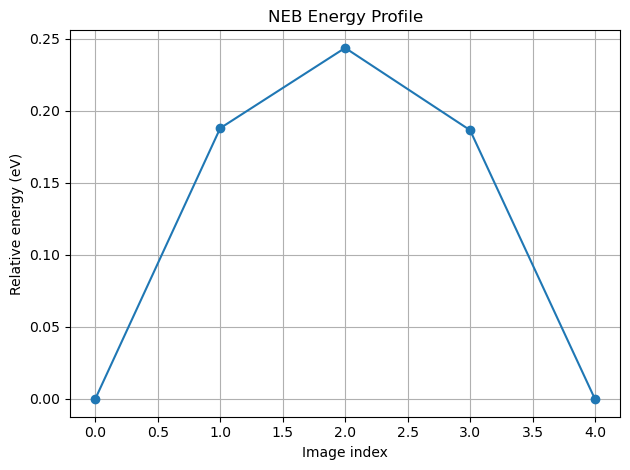

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from ase.io import read, write
from ase.mep import NEB
from ase.optimize import BFGS
from ase.visualize import view
from ase.calculators.espresso import Espresso, EspressoProfile

profile = EspressoProfile(
    command="mpirun --mca btl self,tcp -n 10 pw.x",
    pseudo_dir="../pseudopotentials/qe",
)

# ------------------------------------------------------------
# 1. Read initial and final geometries
# ------------------------------------------------------------
initial = read('gr1_qe.traj')   # or initial.xyz / initial.traj
final   = read('gr2_qe.traj')

os.mkdir("neb_qe")
os.chdir("neb_qe")

# ------------------------------------------------------------
# 2. Create NEB images (initial + 3 intermediates + final)
# ------------------------------------------------------------
n_images = 5
images = [initial]

for i in range(n_images - 2):
    images.append(initial.copy())

images.append(final)

neb = NEB(images)
neb.interpolate()   # linear interpolation

# ------------------------------------------------------------
# 3. Attach a *separate* QE calculator to each image
# ------------------------------------------------------------
def make_qe_calc(label):
    return Espresso(
                        pseudopotentials={'C': 'C.pbe-n-kjpaw_psl.1.0.0.UPF', 'Ni': 'ni_pbe_v1.4.uspp.F.UPF'},
                        profile=profile,
                        input_data={
                            'control': {
                                'calculation': 'scf',
                                'prefix': 'c2_qe',
                                'tstress': True,
                                'tprnfor': True, 
                            },
                            'system': {
                                'ecutwfc': 80,
                                'ecutrho': 4*80,
                                'occupations': 'smearing',
                                'smearing': 'mv',
                                'degauss': 0.02,
                                # no nspin, no starting_magnetization → non‑polarized
                                'assume_isolated': '2D',

                                
                            },
                            'electrons': {
                                'conv_thr': 1e-6,
                                'electron_maxstep': 1000,
                                'mixing_mode': 'local-TF',
                                'mixing_beta': 0.1,
                                'mixing_ndim': 8,
                            }
                        },
                        kpts=(3, 3, 1)
                    )   

for i, img in enumerate(images):
    img.calc = make_qe_calc(f'neb_img_{i}')

# ------------------------------------------------------------
# 4. Optimize the NEB path
# ------------------------------------------------------------
opt = BFGS(neb, logfile='neb.log')
opt.run(fmax=0.05)  # convergence criterion for forces on images

# ------------------------------------------------------------
# 5. Collect energies and compute relative profile
# ------------------------------------------------------------
energies = [img.get_potential_energy() for img in images]
E0 = energies[0]
rel_energies = [E - E0 for E in energies]

# Identify TS (highest energy image)
ts_index = int(np.argmax(energies))
ts_image = images[ts_index]
write('TS.traj', ts_image)

# ------------------------------------------------------------
# 6. Plot NEB energy profile
# ------------------------------------------------------------
plt.figure()
plt.plot(range(n_images), rel_energies, '-o')
plt.xlabel('Image index')
plt.ylabel('Relative energy (eV)')
plt.title('NEB Energy Profile')
plt.grid(True)
plt.tight_layout()
plt.savefig('neb_profile.png', dpi=200)

print("Absolute energies (eV):", energies)
print("TS image index:", ts_index)
print("TS geometry saved as TS.traj")
os.chdir("../")
view(ts_image, viewer='x3d')